In [2]:
import pandas as pd

# Load file
df = pd.read_csv("/Users/ananyagullapally/Documents/hospital-readmissions/FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv")

# Shape
print("Shape:", df.shape)

# Columns
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nDtypes:")
print(df.dtypes)

# Null counts
print("\nNull Counts:")
print(df.isnull().sum())

# First rows
df.head()

Shape: (18330, 12)

Columns:
['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']

Dtypes:
Facility Name                  object
Facility ID                     int64
State                          object
Measure Name                   object
Number of Discharges          float64
Footnote                      float64
Excess Readmission Ratio      float64
Predicted Readmission Rate    float64
Expected Readmission Rate     float64
Number of Readmissions         object
Start Date                     object
End Date                       object
dtype: object

Null Counts:
Facility Name                     0
Facility ID                       0
State                             0
Measure Name                      0
Number of Discharges          10088
Footnote                      11343
Excess Readmission Ratio     

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [4]:
import pandas as pd

# copy
clean_df = df.copy()

# dates
clean_df["Start Date"] = pd.to_datetime(clean_df["Start Date"])
clean_df["End Date"] = pd.to_datetime(clean_df["End Date"])

# numeric cleanup
clean_df["Number of Readmissions"] = pd.to_numeric(
    clean_df["Number of Readmissions"], errors="coerce"
)

# keep rows with actual metrics
model_df = clean_df.dropna(subset=["Excess Readmission Ratio"]).copy()

print("Clean rows with metrics:", model_df.shape)
print(model_df.head())

Clean rows with metrics: (11720, 12)
                     Facility Name  Facility ID State            Measure Name  \
0  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL  READM-30-HIP-KNEE-HRRP   
1  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL      READM-30-CABG-HRRP   
2  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL       READM-30-AMI-HRRP   
3  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL      READM-30-COPD-HRRP   
4  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL        READM-30-PN-HRRP   

   Number of Discharges  Footnote  Excess Readmission Ratio  \
0                   NaN       NaN                    0.9875   
1                 137.0       NaN                    0.9531   
2                 273.0       NaN                    0.9370   
3                 122.0       NaN                    0.9823   
4                 507.0       NaN                    0.9871   

   Predicted Readmission Rate  Expected Readmission Rate  \
0                      4.5734        

In [5]:
model_df["high_risk_flag"] = (
    model_df["Excess Readmission Ratio"] > 1.0
).astype(int)

print(model_df["high_risk_flag"].value_counts())
print(model_df["high_risk_flag"].value_counts(normalize=True)*100)

high_risk_flag
0    6077
1    5643
Name: count, dtype: int64
high_risk_flag
0    51.851536
1    48.148464
Name: proportion, dtype: float64


In [6]:
model_df["report_days"] = (
    model_df["End Date"] - model_df["Start Date"]
).dt.days

model_df["measure_short"] = model_df["Measure Name"].str.replace("-HRRP","", regex=False)

print(model_df[[
    "report_days",
    "measure_short",
    "high_risk_flag"
]].head())

   report_days      measure_short  high_risk_flag
0         1095  READM-30-HIP-KNEE               0
1         1095      READM-30-CABG               0
2         1095       READM-30-AMI               0
3         1095      READM-30-COPD               0
4         1095        READM-30-PN               0


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Features
X = model_df[[
    "State",
    "measure_short",
    "Number of Discharges",
    "Predicted Readmission Rate",
    "Expected Readmission Rate",
    "Number of Readmissions"
]]

y = model_df["high_risk_flag"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = [
    "Number of Discharges",
    "Predicted Readmission Rate",
    "Expected Readmission Rate",
    "Number of Readmissions"
]

cat_cols = [
    "State",
    "measure_short"
]

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

model = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=250,
        random_state=42
    ))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

Accuracy: 0.9035836177474402
ROC AUC: 0.9665795507149705
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1215
           1       0.91      0.88      0.90      1129

    accuracy                           0.90      2344
   macro avg       0.90      0.90      0.90      2344
weighted avg       0.90      0.90      0.90      2344



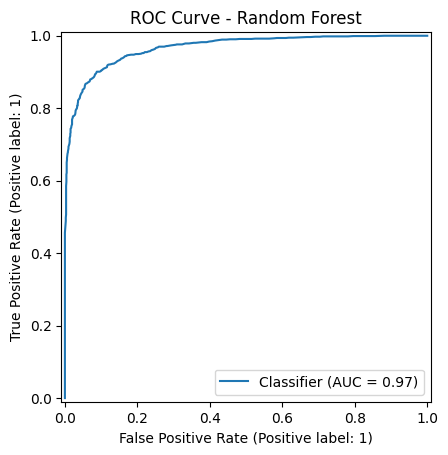

In [8]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, proba)
plt.title("ROC Curve - Random Forest")
plt.show()